In [77]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load the dataset
df = pd.read_csv(r'C:\Users\Madhusmita Barik\Desktop\python_files\ml-assessment-madhusmita-barik\data\q1_heart_disease.csv')

# Step 3: Display shape
print("Shape of dataset:")
print(df.shape)

# Step 4: Display data types
print("\nData Types:")
print(df.dtypes)

# Step 5: Display missing values count
print("\nMissing Values:")
print(df.isnull().sum())

# Step 6: Show first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

Shape of dataset:
(800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       1

## Exploratory Data Analysis

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic check
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Target Class Distribution Plot

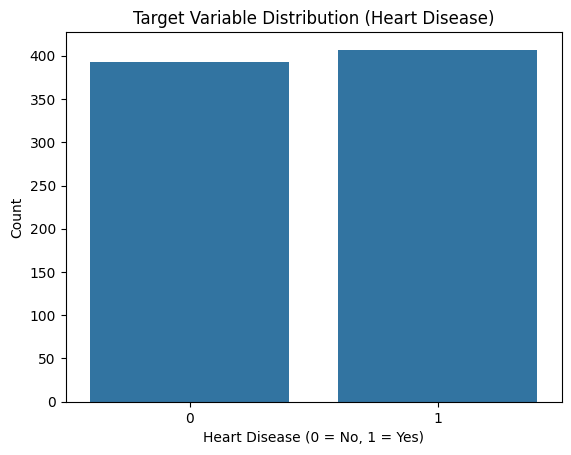

In [79]:
plt.figure()
sns.countplot(x='heart_disease', data=df)
plt.title("Target Variable Distribution (Heart Disease)")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


#### Interpretation
1. The dataset is fairly balanced between patients with heart disease (1) and without (0).
2. There is no severe class imbalance, which is good because:
    - Models trained on this data will not be biased toward one class.
    - No immediate need for resampling techniques like SMOTE or undersampling.
3. Slightly more cases of heart disease (1) are present, but the difference is minimal.

### Correlation Heatmap

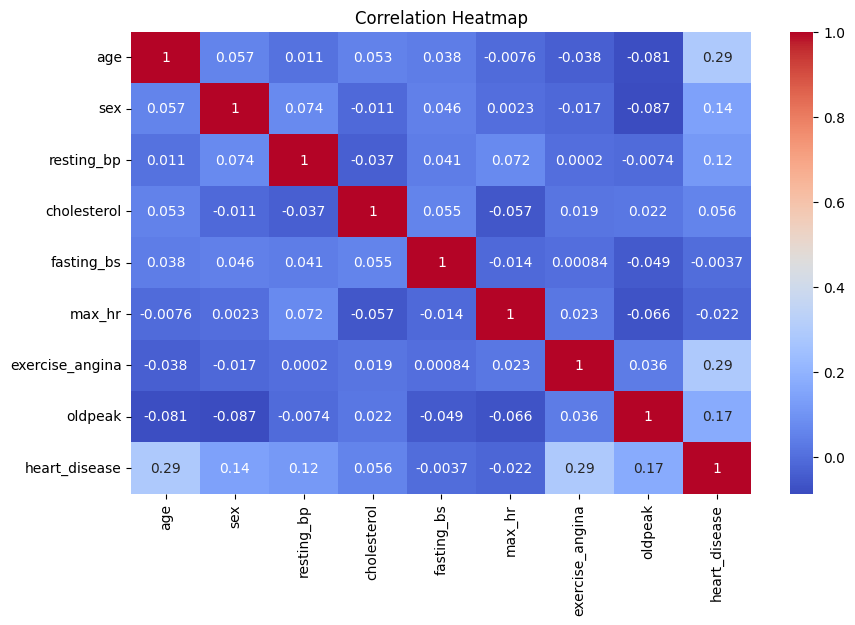

In [80]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#### Interpretation (Markdown Cell)
1. Most features show weak to moderate correlation with the target (heart_disease).
2. The strongest positive correlations with heart disease are: 
    age (~0.29) → older individuals have higher risk
    exercise_angina (~0.29) → strong indicator of heart disease
    oldpeak (~0.17) → some predictive signal
    sex (~0.14) → mild relationship
3. Features like:
cholesterol, fasting_bs, and max_hr show very weak correlation, meaning they may contribute less individually.
4. There is no strong multicollinearity between independent variables, which is good for models like Logistic Regression.

### Age Distribution (Histogram)

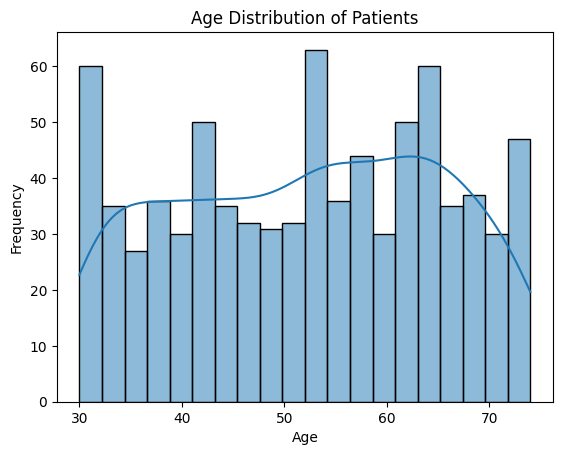

In [81]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### Interpretation
1. Age is spread roughly between 30 to 75 years.
2. Most patients fall in the 40–65 age range, indicating:
3. Heart disease risk is more relevant in middle-aged and older individuals.
4. The distribution is fairly smooth (no extreme skew), so:
5. No heavy transformation is required.
6. Slight concentration in higher age groups supports the earlier correlation observation that age impacts heart disease risk.

### Heart Disease vs Chest Pain Type

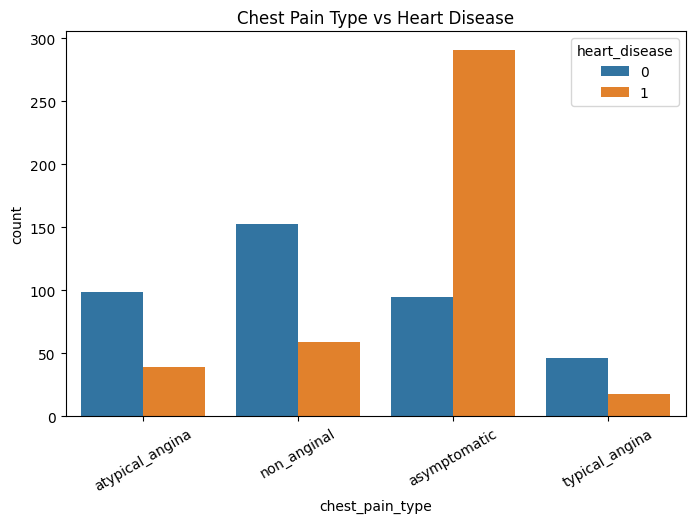

In [82]:
plt.figure(figsize=(8,5))
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=30)
plt.show()

#### Interpretation
1. Different chest pain types show varying associations with heart disease.
2. Certain categories (like asymptomatic) are having higher disease presence.
3. This feature is likely important for prediction.

## Data Preprocessing 

### Handle Missing Values
-> Justification
1. The dataset has missing values in resting_bp and cholesterol.
2.We use median imputation because:
3. These are numerical features.
4. Median is robust to outliers, unlike mean.
5. Dropping rows would lead to data loss (~7%), which is unnecessary for this dataset size.

In [83]:
# Fill missing values using median

df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# Verify
df.isnull().sum()

age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64

### One-Hot Encoding
-> Justification:
1. Categorical columns (chest_pain_type, resting_ecg, st_slope)are converted into numerical format using one-hot encoding.
2. This avoids introducing ordinal relationships where none exist.

In [84]:
# One-hot encode categorical columns
categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142.0,399.0,0,169,0,0.4,1,True,False,False,False,False,False,True
1,58,1,163.0,310.0,1,121,1,1.1,1,False,True,False,False,True,False,True
2,44,1,128.0,175.0,0,183,1,0.2,0,False,True,False,True,False,False,True
3,72,1,114.0,177.0,0,150,0,1.0,1,False,False,False,False,True,False,True
4,37,1,149.0,271.0,0,136,0,0.4,0,False,True,False,True,False,True,False


### Feature Scaling
-> Justification:
1. Numerical features are scaled using StandardScaler:
2. Centers data around mean = 0 and std = 1
3. Improves performance for models like Logistic Regression, SVM, KNN

In [85]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Identify numerical columns
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,1.229854,0,0.702830,3.000527,0,0.887081,0,-0.585809,True,False,False,False,False,False,True
1,0.451896,1,2.003076,1.258794,1,-1.257462,1,0.194526,False,True,False,False,True,False,True
2,-0.637245,1,-0.164001,-1.383161,0,1.512573,1,-0.808762,False,True,False,True,False,False,True
3,1.541037,1,-1.030832,-1.344021,0,0.038200,0,0.083050,False,False,False,False,True,False,True
4,-1.181815,1,1.136245,0.495562,0,-0.587292,0,-0.585809,False,True,False,True,False,True,False


### Train-Test Split
-> Justification: 
We split data into training and testing sets using:
1. stratify=y → maintains class balance
2. random_state=42 → ensures reproducibility

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (640, 15)
X_test: (160, 15)
y_train: (640,)
y_test: (160,)


## Model Training

In [87]:
# Imports models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize Models (with random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train the Models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Make Predictions
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

### Justification:
1. Three different models were trained:
    Decision Tree: Simple, interpretable, but prone to overfitting
    Random Forest: Ensemble of trees → reduces overfitting and improves accuracy
    Gradient Boosting: Sequential boosting → often gives high performance
2. random_state=42 ensures:
    Reproducibility of results
    Same splits and model behavior across runs

## Model Evaluation

In [88]:
# Import matrix
from sklearn.metrics import confusion_matrix, classification_report

#Decision Tree Evaluation
print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Confusion Matrix:
[[56 23]
 [25 56]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



-> Confusion Matrix Insight
1. True Negatives (TN): 56
2. False Positives (FP): 23
3. False Negatives (FN): 25
4. True Positives (TP): 56
The model makes a moderate number of misclassifications in both classes.

-> Performance Metrics
1. Accuracy: 70%
2. Precision (Class 1): 0.71
3. Recall (Class 1): 0.69
4. F1-score: 0.70
Interpretation:

Performance is moderate and balanced across both classes.
Similar precision and recall indicate no strong bias toward either class.
However, relatively high FP and FN suggest:
The model struggles to generalize well
Likely overfitting (common in decision trees)

In [89]:
# Random Forest Evaluation
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Confusion Matrix:
[[61 18]
 [15 66]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



-> Confusion Matrix Insight
1. True Negatives (TN): 61
2. False Positives (FP): 18
3. False Negatives (FN): 15
4. True Positives (TP): 66
Fewer misclassifications compared to Decision Tree, especially:

Lower FN (better detection of heart disease)
Lower FP (fewer false alarms)

-> Performance Metrics
1. Accuracy: 79%
2. Precision (Class 1): 0.79
3. Recall (Class 1): 0.81
F1-score: 0.80

Significant improvement over Decision Tree.
Higher recall (0.81) → better at identifying patients with heart disease
Balanced precision and recall → robust model performance
Ensemble method reduces overfitting → better generalization

In [90]:
# Gradient Boosting Evaluation
print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Confusion Matrix:
[[61 18]
 [19 62]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



-> Confusion Matrix Insight
1. True Negatives (TN): 61
2. False Positives (FP): 18
3. False Negatives (FN): 19
4. True Positives (TP): 62

Compared to others:

Slightly more false negatives than Random Forest
Similar false positives to Random Forest

-> Performance Metrics
1. Accuracy: 77%
2. Precision (Class 1): 0.78
3. Recall (Class 1): 0.77
4. F1-score: 0.77


Performance is strong and balanced across both classes.
Slightly lower recall than Random Forest → misses more actual heart disease cases.
Still better than Decision Tree, but not the best overall.

### Compare all models together:

In [91]:
from sklearn.metrics import accuracy_score

print("DT Accuracy:", accuracy_score(y_test, dt_pred))
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("GB Accuracy:", accuracy_score(y_test, gb_pred))

DT Accuracy: 0.7
RF Accuracy: 0.79375
GB Accuracy: 0.76875


-> The Random Forest Classifier performs the best overall among the three models.

-> It achieves:

    1. Highest accuracy (79%)
    2. Best recall (0.81) → most important in medical prediction
    3. Strong precision and F1-score

-> Gradient Boosting performs well but slightly underperforms compared to Random Forest.

-> Decision Tree shows the weakest performance due to:
    1. Higher misclassification rates
    2. Overfitting tendency

## Hyperparameter Tuning

We tune key hyperparameters:

n_estimators → number of trees

max_depth → controls overfitting

min_samples_split → minimum samples to split a node

In [92]:
# Import
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Run GridSearchCV
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", grid_search.best_params_)

#Evaluate Tuned Model
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print("Tuned Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

print("\nTuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Tuned Model Confusion Matrix:
[[58 21]
 [15 66]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        79
           1       0.76      0.81      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160


Tuned Accuracy: 0.775


The tuned model:

1. Maintains same recall (0.81) → still strong at detecting heart disease
2. Slightly reduces precision and accuracy
3. Introduces more false positives

This indicates:

1. Tuning made the model slightly more generalized, but
2. Did not improve overall performance


### Conclusion:


GridSearchCV identified optimal hyperparameters for the Random Forest model.
However, the tuned model did not outperform the baseline model on the test set.

The baseline Random Forest:

1. Has higher accuracy (79%)
2. Better precision
3. Same recall

-> Therefore, the untuned (baseline) Random Forest remains the preferred model.